##In this file, we analyzed the model’s performance on these random inputs.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.ma as ma
import tensorflow as tf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
path='/content/drive/My Drive/Work7_MAUNet_Light_Data_Model_Result'
BiasData_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_BiasData_Test_TRMMIMD.npy')
Label_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_Label_Test_TRMMIMD.npy')

In [ ]:
datamask=np.load(path+"/Data/Mask-TRMM128x128.npy")

In [ ]:
temporal_random_input_data=np.load(path+"/Data/temporal_random_input_data.npy")
spatial_random_input_data=np.load(path+"/Data/spatial_random_input_data.npy")

In [ ]:
temporal_rand_result = np.load(path+"/Result/RandomSample/Gridded/t_random_MAUNet_Light_KR_result.npy")
spatial_rand_result=np.load(path+"/Result/RandomSample/Gridded/s_random_MAUNet_Light_KR_result.npy")
MAUNet_Light_KR_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_KR_TRMMIMD_TestResult.npy')

In [ ]:
testmask=[]
for i in range(len(Label_Test_Grid)):
  testmask.append(datamask)
testmask=np.array(testmask)

In [ ]:
Masked_Spatial_Random_Result=ma.masked_array(spatial_rand_result, mask=testmask)
Masked_Temporal_Random_Result=ma.masked_array(temporal_rand_result, mask=testmask)
Masked_BiasData_Test_Grid=ma.masked_array(BiasData_Test_Grid, mask=testmask)
Masked_Label_Test_Grid=ma.masked_array(Label_Test_Grid, mask=testmask)
Masked_MAUNet_Light_KR_Test_Grid=ma.masked_array(MAUNet_Light_KR_Test_Grid, mask=testmask)
Masked_Spatial_Random_Input=ma.masked_array(spatial_random_input_data, mask=testmask)
Masked_Temporal_Random_Input=ma.masked_array(temporal_random_input_data, mask=testmask)

In [ ]:
tmean_test=[]
smean_test=[]

for i in range(610):
  tmean_test.append(np.mean(Masked_Temporal_Random_Result[i][~Masked_Temporal_Random_Result[i].mask]))
  smean_test.append(np.mean(Masked_Spatial_Random_Result[i][~Masked_Spatial_Random_Result[i].mask]))


In [ ]:
tmean_test_input=[]
smean_test_input=[]

for i in range(610):
  tmean_test_input.append(np.mean(Masked_Temporal_Random_Input[i][~Masked_Temporal_Random_Input[i].mask]))
  smean_test_input.append(np.mean(Masked_Spatial_Random_Input[i][~Masked_Spatial_Random_Input[i].mask]))

In [ ]:
# np.save(path+'/Result/RandomSample/SpatialMean/Work7_SpatialMean_MAUNet_Light_KR_Temporal_Random_Result.npy', tmean_test)
# np.save(path+'/Result/RandomSample/SpatialMean/Work7_SpatialMean_MAUNet_Light_KR_Spatial_Random_Result.npy', smean_test)

In [ ]:
# np.save(path+'/Result/RandomSample/SpatialMean/Work7_SpatialMean_Temporal_Random_Input.npy', tmean_test_input)
# np.save(path+'/Result/RandomSample/SpatialMean/Work7_SpatialMean_Spatial_Random_Input.npy', smean_test_input)

In [ ]:
BiasData_Test_Mean=np.load(path+'/Result/SpatialMean/Work7_SpatialMean_BiasData_Test_TRMMIMD.npy')
Label_Test_Mean=np.load(path+'/Result/SpatialMean/Work7_SpatialMean_Label_Test_TRMMIMD.npy')
MAUNet_Light_KR_Test_Mean=np.load(path+'/Result/SpatialMean/Work7_SpatialMean_MAUNet_Light_KR_TRMMIMD_TestResult.npy')

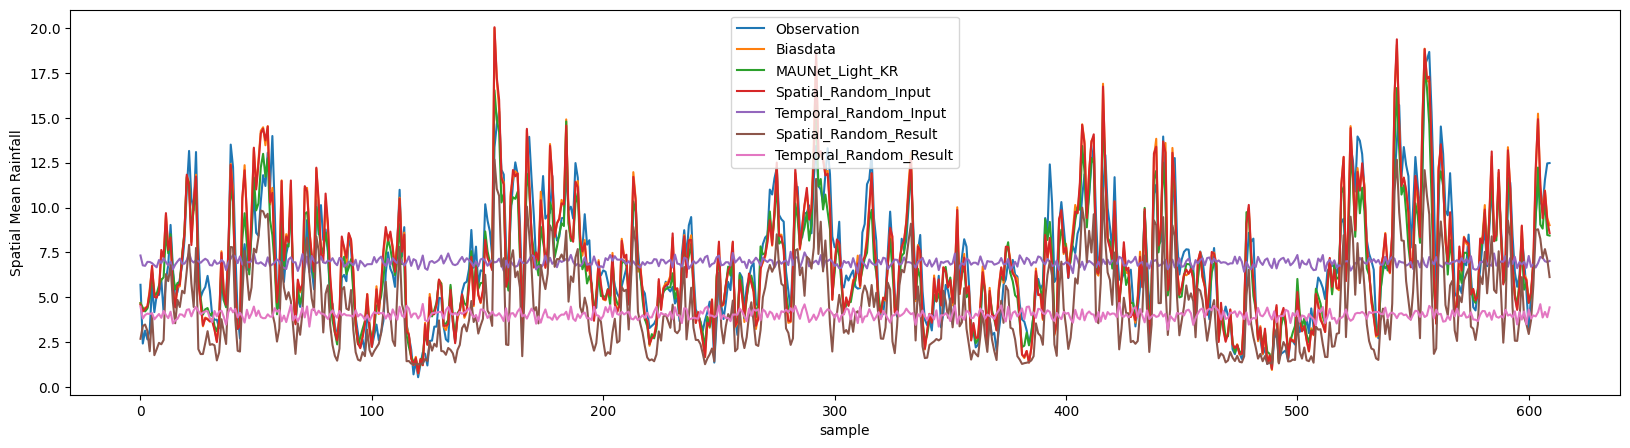

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(Label_Test_Mean,label='Observation')
plt.plot(BiasData_Test_Mean, label='Biasdata')
plt.plot(MAUNet_Light_KR_Test_Mean, label='MAUNet_Light_KR')
plt.plot(smean_test_input,label='Spatial_Random_Input')
plt.plot(tmean_test_input,label='Temporal_Random_Input')
plt.plot(smean_test,label='Spatial_Random_Result')
plt.plot(tmean_test,label='Temporal_Random_Result')
plt.xlabel('sample')
plt.ylabel('Spatial Mean Rainfall')
plt.legend()

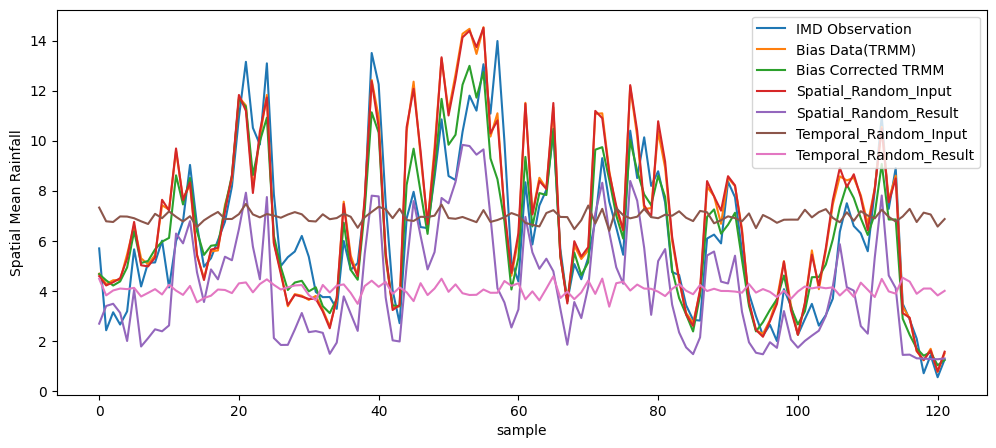

In [ ]:
#FOR THE YEAR 2015
plt.figure(figsize=(12, 5))
plt.plot(Label_Test_Mean[:122],label='IMD Observation')
plt.plot(BiasData_Test_Mean[:122], label='Bias Data(TRMM)')
plt.plot(MAUNet_Light_KR_Test_Mean[:122], label='Bias Corrected TRMM')
plt.plot(smean_test_input[:122],label='Spatial_Random_Input')
plt.plot(smean_test[:122],label='Spatial_Random_Result')
plt.plot(tmean_test_input[:122],label='Temporal_Random_Input')
plt.plot(tmean_test[:122],label='Temporal_Random_Result')

plt.xlabel('sample')
plt.ylabel('Spatial Mean Rainfall')
plt.legend()

In [ ]:
def mean_cal(Data,Mask):
  sum_value=0
  count=0
  for i in range(128):
    for j in range(128):
      if Mask[i,j]==0 and np.isnan(Data[i,j])==False:
        sum_value=sum_value+Data[i,j]
        count=count+1
  mean_value=np.round((sum_value/count),4)
  return mean_value

#Grid_wise mean rainfall value calculation

In [ ]:
def climatology_gridwise(arr):
  mean_grid=np.mean(arr,axis=0)
  return mean_grid


In [ ]:
#Calculate climatology at each GRID location
climatology_GT_Test_Grid=climatology_gridwise(Label_Test_Grid)
climatology_Spatial_Random_Input_Grid=climatology_gridwise(spatial_random_input_data)
climatology_Spatial_Random_Result_Grid=climatology_gridwise(spatial_rand_result)
climatology_Temporal_Random_Input_Grid=climatology_gridwise(temporal_random_input_data)
climatology_Temporal_Random_Result_Grid=climatology_gridwise(temporal_rand_result)
climatology_BiasData_Test_Grid=climatology_gridwise(BiasData_Test_Grid)
climatology_MAUNet_Light_KR_Test_Grid=climatology_gridwise(MAUNet_Light_KR_Test_Grid)


In [ ]:
#Mask the climatology value
import numpy.ma as ma
MClimatology_GT_Test_Grid=ma.masked_array(climatology_GT_Test_Grid, mask=datamask)
MClimatology_Spatial_Random_Input_Grid=ma.masked_array(climatology_Spatial_Random_Input_Grid, mask=datamask)
MClimatology_Spatial_Random_Result_Grid=ma.masked_array(climatology_Spatial_Random_Result_Grid, mask=datamask)
MClimatology_Temporal_Random_Input_Grid=ma.masked_array(climatology_Temporal_Random_Input_Grid, mask=datamask)
MClimatology_Temporal_Random_Result_Grid=ma.masked_array(climatology_Temporal_Random_Result_Grid, mask=datamask)
MClimatology_MAUNet_Light_KR_Test_Grid = ma.masked_array(climatology_MAUNet_Light_KR_Test_Grid, mask=datamask)
MClimatology_BiasData_Test_Grid = ma.masked_array(climatology_BiasData_Test_Grid, mask=datamask)


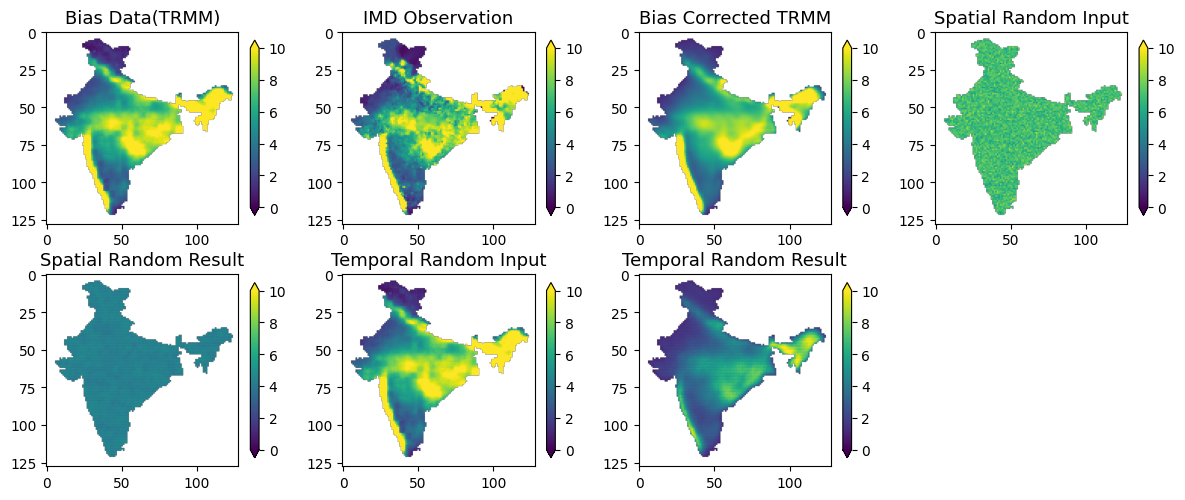

In [ ]:
import matplotlib.pyplot as plt
import numpy.ma as ma


# --- Plot setup ---
cmap = plt.get_cmap("viridis")  # continuous colormap
vmin, vmax = 0, 10  # rainfall range

# Create 3x3 subplot grid
fig, axs = plt.subplots(2, 4, figsize=(12, 5))

# Define the grids to plot
grids = [
    ("Bias Data(TRMM)", MClimatology_BiasData_Test_Grid),
    ("IMD Observation", MClimatology_GT_Test_Grid),
    ("Bias Corrected TRMM", MClimatology_MAUNet_Light_KR_Test_Grid),
    ("Spatial Random Input", MClimatology_Spatial_Random_Input_Grid),
    ("Spatial Random Result", MClimatology_Spatial_Random_Result_Grid),
    ("Temporal Random Input", MClimatology_Temporal_Random_Input_Grid),
    ("Temporal Random Result", MClimatology_Temporal_Random_Result_Grid),
]

# Plot each grid
for ax, (title, grid) in zip(axs.flat, grids):
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax)  # continuous color map
    ax.set_title(title, fontsize=13)
    ax.tick_params(labelsize=10)
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", extend="both", shrink=0.9)
    cbar.ax.tick_params(labelsize=10)

# Hide any remaining empty subplots
for ax in axs.flat[len(grids):]:
    ax.axis("off")

# Adjust layout
plt.tight_layout()
plt.show()


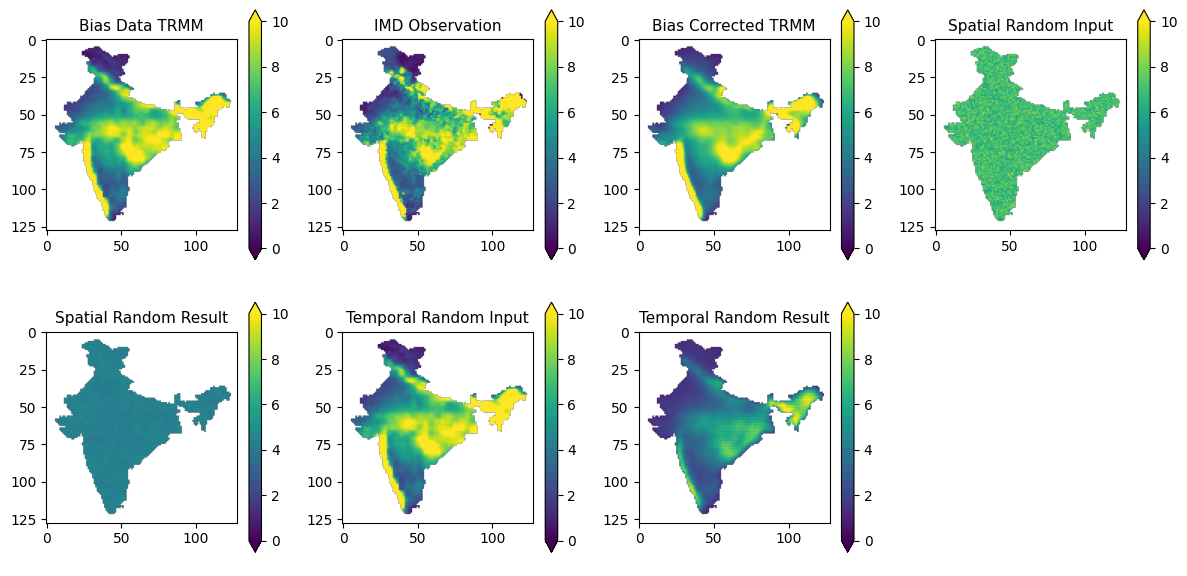

In [ ]:
import matplotlib.pyplot as plt
import numpy.ma as ma


# --- Plot setup ---
cmap = plt.get_cmap("viridis")  # continuous colormap
vmin, vmax = 0, 10  # rainfall range

# Define the grids to plot
grids = [
    ("Bias Data TRMM", MClimatology_BiasData_Test_Grid),
    ("IMD Observation", MClimatology_GT_Test_Grid),
    ("Bias Corrected TRMM", MClimatology_MAUNet_Light_KR_Test_Grid),
    ("Spatial Random Input", MClimatology_Spatial_Random_Input_Grid),
    ("Spatial Random Result", MClimatology_Spatial_Random_Result_Grid),
    ("Temporal Random Input", MClimatology_Temporal_Random_Input_Grid),
    ("Temporal Random Result", MClimatology_Temporal_Random_Result_Grid),
]

# Determine grid size (rows and columns) dynamically
n_plots = len(grids)
n_cols = 4
n_rows = 2  # ceiling division

fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 6))
axs = axs.flatten()  # flatten in case of multiple rows

# Plot each grid
for ax, (title, grid) in zip(axs, grids):
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax)  # continuous color map
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=10)
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", extend="both", shrink=0.9)
    cbar.ax.tick_params(labelsize=10)

# Hide any remaining empty subplots (if any)
for ax in axs[n_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


##Correlation Maps

In [ ]:
import scipy.stats.mstats as cm

In [ ]:
testmask=[]
for i in range(len(Label_Test_Grid)):
  testmask.append(datamask)

In [ ]:
#Spatial correlation gridwise training set
def grid_corr(r,l):
  corr_test_r_l=np.full((128, 128), np.nan)
  for i in range(128):
   for j in range(128):
    if datamask[i,j]==0:
     corr_test_r_l[i,j]=cm.pearsonr(r[:,i,j],l[:,i,j])[0]
  return corr_test_r_l

In [ ]:
Masked_Spatial_Random_Result=ma.masked_array(spatial_random_result, mask=testmask)
Masked_Temporal_Random_Result=ma.masked_array(temporal_random_result, mask=testmask)
Masked_BiasData_Test_Grid=ma.masked_array(BiasData_Test_Grid, mask=testmask)
Masked_Label_Test_Grid=ma.masked_array(Label_Test_Grid, mask=testmask)
Masked_MAUNet_Light_KR_Test_Grid=ma.masked_array(MAUNet_Light_KR_Test_Grid, mask=testmask)
Masked_Spatial_Random_Input=ma.masked_array(spatial_random_input_data, mask=testmask)
Masked_Spatial_Random_Inpu=ma.masked_array(temporal_random_input_data, mask=testmask)

In [ ]:
BIASDATA_Corr_Grid= grid_corr(Masked_BiasData_Test_Grid,Masked_Label_Test_Grid)
spatial_random_input_Corr_Grid=grid_corr(Masked_Spatial_Random_Input,Masked_Label_Test_Grid)
spatial_rand_result_Corr_Grid=grid_corr(Masked_Spatial_Random_Result,Masked_Label_Test_Grid)
temporal_random_input_Corr_Grid=grid_corr(Masked_Spatial_Random_Input,Masked_Label_Test_Grid)
temporal_rand_result_Corr_Grid=grid_corr(Masked_Temporal_Random_Result,Masked_Label_Test_Grid)
MAUNet_Light_KR_Corr_Grid=grid_corr(Masked_MAUNet_Light_KR_Test_Grid,Masked_Label_Test_Grid)


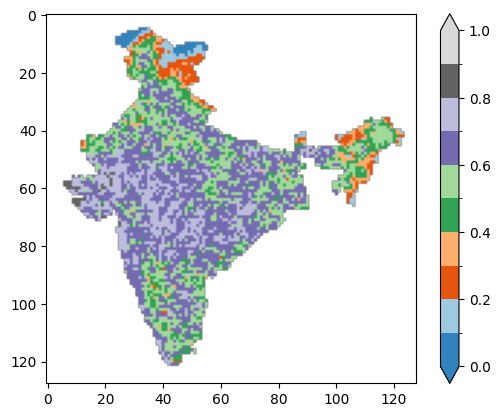

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20c"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(BIASDATA_Corr_Grid, cmap=cmap, norm=norm)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical", extend='both')

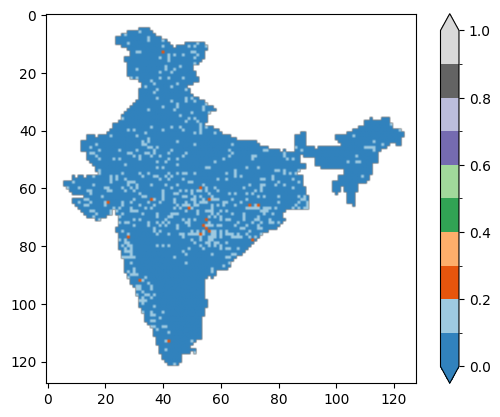

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20c"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(spatial_random_input_Corr_Grid, cmap=cmap, norm=norm)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical", extend='both')

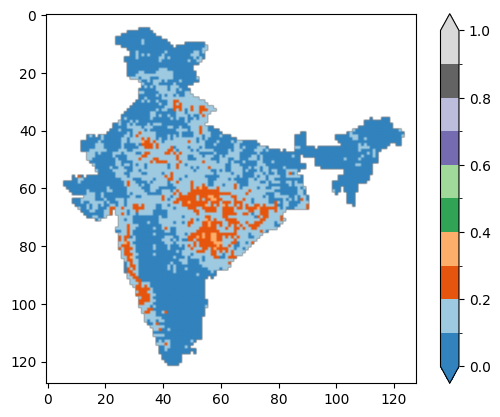

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20c"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(spatial_rand_result_Corr_Grid, cmap=cmap, norm=norm)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical", extend='both')

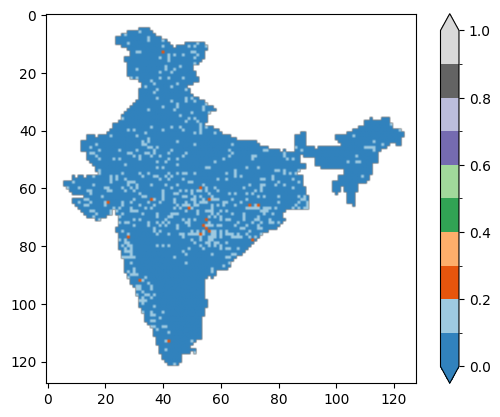

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20c"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(temporal_random_input_Corr_Grid, cmap=cmap, norm=norm)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical", extend='both')

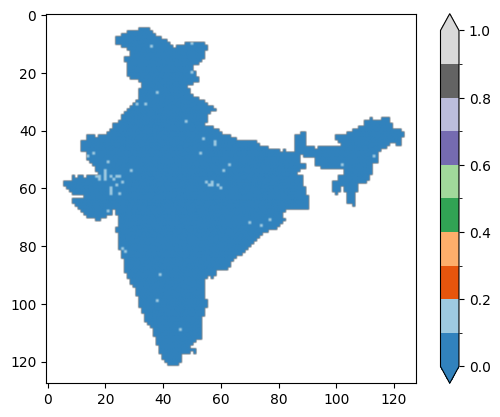

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20c"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(temporal_rand_result_Corr_Grid, cmap=cmap, norm=norm)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical", extend='both')

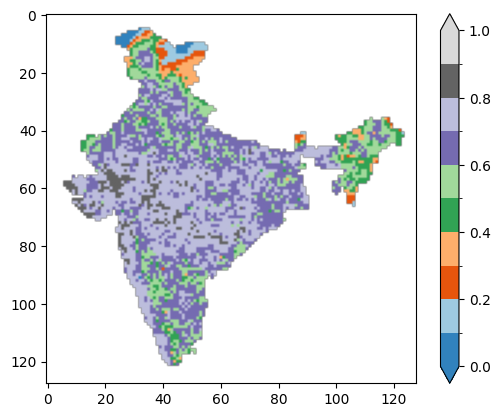

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20c"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(MAUNet_Light_KR_Corr_Grid, cmap=cmap, norm=norm)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical", extend='both')

In [ ]:

Grid_Corr_S_Mean_MAUNet_Light_KR_Ts=mean_cal(MAUNet_Light_KR_Corr_Grid,datamask)
Grid_Corr_S_Mean_Spatial_Random_Input_Ts=mean_cal(spatial_random_input_Corr_Grid,datamask)
Grid_Corr_S_Mean_Spatial_Random_Result_Ts=mean_cal(spatial_rand_result_Corr_Grid,datamask)
Grid_Corr_S_Mean_Temporal_Random_Input_Ts=mean_cal(temporal_random_input_Corr_Grid,datamask)
Grid_Corr_S_Mean_Temporal_Random_Result_Ts=mean_cal(temporal_rand_result_Corr_Grid,datamask)
Grid_Corr_S_Mean_BiasData_Ts=mean_cal(BIASDATA_Corr_Grid,datamask)

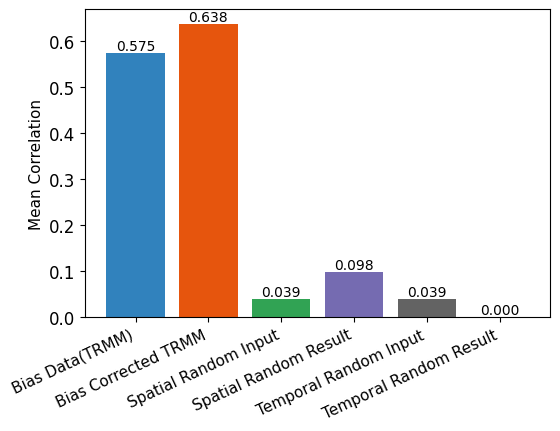

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Prepare data for plotting
labels = [
    "Bias Data(TRMM)",
    "Bias Corrected TRMM",
    "Spatial Random Input",
    "Spatial Random Result",
    "Temporal Random Input",
    "Temporal Random Result"
]

values = [
    Grid_Corr_S_Mean_BiasData_Ts,
    Grid_Corr_S_Mean_MAUNet_Light_KR_Ts,
    Grid_Corr_S_Mean_Spatial_Random_Input_Ts,
    Grid_Corr_S_Mean_Spatial_Random_Result_Ts,
    Grid_Corr_S_Mean_Temporal_Random_Input_Ts,
    Grid_Corr_S_Mean_Temporal_Random_Result_Ts

]

# Plot settings
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=plt.cm.tab20c(np.linspace(0, 1, len(labels))))

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}",
             ha='center', va='bottom', fontsize=10)

# Formatting
plt.ylabel("Mean Correlation", fontsize=11)
#plt.title("Comparison of Mean Correlation Across Models", fontsize=15, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=12)
#plt.grid(axis='y', linestyle='--', alpha=0.6)
#plt.tight_layout()

plt.show()
